In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request

In [2]:
def blend_numpy(img1, img2, alpha=0.5, beta=0.5, gamma=0):
    a = img1.astype(np.float64)
    b = img2.astype(np.float64)

    blended = alpha * a + beta * b + gamma
    blended = np.clip(blended, 0, 255)

    return blended.astype(np.uint8)

In [3]:
def load_image_from_url(url):
    response = urllib.request.urlopen(url)
    data = np.asarray(bytearray(response.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

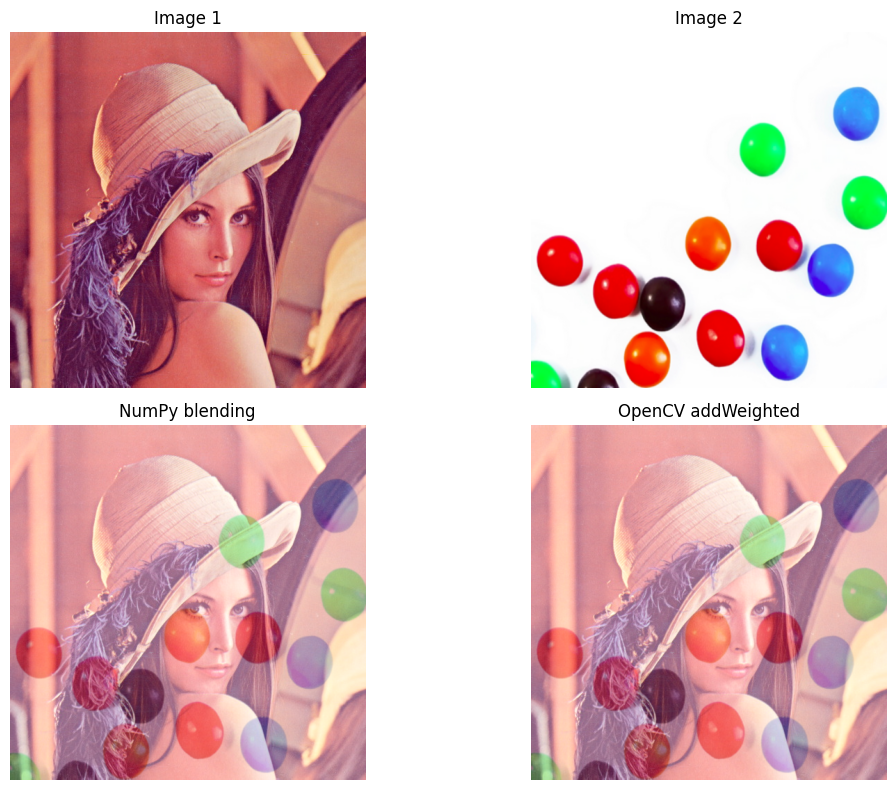

In [4]:
url1 = "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fi.ytimg.com%2Fvi%2FSp1HQeBHjhM%2Fmaxresdefault.jpg&f=1&nofb=1&ipt=3898bafc8bbe94ca1e4da202567248ddd9f765425045a159acdf88072a07e0a3"
url2 =     "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Findiecatorhome.files.wordpress.com%2F2023%2F08%2Flinus-e1692337608336.jpg%3Fw%3D1024&f=1&nofb=1&ipt=c2cc0a8a5b62f13dd45d19f721fff3f4c5c3fcd015f7dfe11f998a87b322fc7d"

img1 = load_image_from_url(url1)
img2 = load_image_from_url(url2)

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

alpha = 0.7
beta = 0.3
gamma = 20

result_numpy = blend_numpy(img1, img2, alpha=alpha, beta=beta, gamma=gamma)
result_opencv = cv2.addWeighted(img1, alpha, img2, beta, gamma)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img2)
plt.title("Image 2")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(result_numpy)
plt.title("NumPy blending")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(result_opencv)
plt.title("OpenCV addWeighted")
plt.axis("off")

plt.tight_layout()
plt.show()